# NER on OCR output — zero-shot workflow

**Goal:** run named entity recognition over the assembled OCR text (`OCR/ocr-project/assembled/body.txt`)
without any labeled training data, then measure whether the off-the-shelf model is good enough
before deciding to annotate + fine-tune.

**Workflow**
1. Load the assembled OCR text (`body.txt` — the version without page headers).
2. Light, conservative OCR cleanup (footnote markers misread as `*`, `!`, `?`).
3. Sentence segmentation.
4. Zero-shot NER with `flair/ner-german-large` (XLM-R Large fine-tuned for German NER).
5. Explore predictions: counts, top entities, low-confidence mentions, highlighted examples.
6. Export a review sample for manual checking → precision/recall estimate → decide whether fine-tuning is needed.
7. Export predictions as pre-annotations (doccano JSONL) so any future labeling starts from corrections, not from scratch.

Everything runs locally in Python — no external services. The first model load downloads ~2.2 GB from Hugging Face.

In [1]:
# Run once per environment (safe to re-run; skip if already installed)
%pip install -q flair pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import flair

# --- Config ---------------------------------------------------------------
DATA_PATH = Path("OCR/ocr-project/assembled/body.txt")
if not DATA_PATH.exists():  # fallback if the notebook is opened from elsewhere
    DATA_PATH = Path("/Users/diazm/Documents/ETH/NER/OCR/ocr-project/assembled/body.txt")

OUT_DIR = Path("ner_outputs")
OUT_DIR.mkdir(exist_ok=True)

SEED = 42
REVIEW_SAMPLE_SIZE = 150

# --- Device ---------------------------------------------------------------
# Apple's MPS backend is deliberately NOT used: flair 0.15 / torch 2.13 hit a
# tensor-shape bug there ("The expanded size of the tensor (N) must match the
# existing size (M)") when a batch mixes sentences of different subtoken
# lengths. CPU tags this corpus in a few seconds, so nothing is lost.
if torch.cuda.is_available():
    flair.device = torch.device("cuda")
else:
    flair.device = torch.device("cpu")
print("flair device:", flair.device)
print("data file:   ", DATA_PATH.resolve())

/Users/diazm/anaconda3/envs/ner/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


flair device: cpu
data file:    /Users/diazm/Documents/ETH/NER/OCR/ocr-project/assembled/body.txt


## 1. Load the assembled OCR text

`assembled/` contains three variants: `full.txt` (with page headers like *"St. Fiden 193"*),
`reading.txt`, and `body.txt`. We use **`body.txt`** — running text without page furniture,
which would otherwise pollute the entity list (page-header place names inflate LOC counts).

In [3]:
raw_text = DATA_PATH.read_text(encoding="utf-8")
print(f"{len(raw_text):,} characters, {len(raw_text.split()):,} whitespace tokens\n")
print(raw_text[:600])

25,014 characters, 3,669 whitespace tokens

Geschichte und Baugeschichte. St. Fiden wurde erst im Jahre 1918 durch die Eingemeindung von Tablat, dem die Siedlung zugehörte, ein Teil des Stadtgebietes. Die Grenze zwischen dem alten Stadtterritorium und der Landschaft ging mitten durch ein zunächst der Kirche gelegenes Haus hindurch, das im Jahre 1426 durch einen Spruch der Räte der städtischen Gerichtsbarkeit zugeteilt wurde (Vad. I, S.365). Die Ortschaft verdankte, wie schon der Name erkennen läßt, allein der Kirche, die bis 1777 den Titel St. Fiden trug, ihr Dasein. Ehemals hieß die Gegend «Eichbohl» (Eichenhügel) oder auch «Farna»!, D


## 2. Light OCR cleanup

The text is 20th-century scholarly German — the *language* needs no normalization.
What does need fixing are footnote markers the OCR misread and glued onto words:

- superscript footnote digits misread as `!` or `?` → `«Farna»!,` / `ruhten?,` / `Turm?.` / `vollendet!?,` / `Jahrhunderts? ist`
- `*` footnote markers stuck to word ends → `Zusammenhang*.` / `Glocke* und`
- occasional real superscripts that survived → `1707¹`

These matter for NER because a stray `!`/`*` inside a token can break entity boundaries.
We stay **conservative**: only patterns that cannot be real German punctuation are touched
(genuine uncertainty markers like *(St. Ludwig?)* are left alone), and every replacement
is printed below for eyeballing before it is applied.

In [ ]:
# OCR footnote artifacts, verified against this corpus. German never has '!'/'?'
# directly before ',' or '.', and a '?' followed by a lowercase word mid-sentence
# is a misread superscript footnote digit. Genuine uncertainty markers like
# "(St. Ludwig?)" or "…oder Walburga? Umschrift…" are deliberately NOT matched.
PATTERNS = [
    ("footnote '*' glued to a word", re.compile(r"(?<=[\wäöüÄÖÜß»)])\*")),
    ("'!'/'?'/'*' before ',' or '.'", re.compile(r"\s?[!?*]+(?=[.,])")),
    ("'?' mid-sentence before lowercase", re.compile(r"(?<=[a-zäöüß])\?(?=\s[a-zäöüß])")),
    ("surviving superscript digits", re.compile(r"[¹²³⁴⁵⁶⁷⁸⁹⁰]+")),
    ("footnote quote/degree marks (1777‘. / 1779°.)", re.compile(r"(?<=[\wäöüß])[‘'`°](?=[.,])")),
]

def show_matches(pattern, text, label, width=40):
    hits = list(pattern.finditer(text))
    print(f"{label}: {len(hits)} match(es)")
    for m in hits[:20]:
        s = max(0, m.start() - width)
        print("   …", text[s : m.end() + width].replace("\n", " "), "…")
    print()

clean_text = raw_text
for label, pattern in PATTERNS:
    show_matches(pattern, clean_text, label)
    clean_text = pattern.sub("", clean_text)
clean_text = re.sub(r"[ \t]{2,}", " ", clean_text)
print(f"cleaned: {len(raw_text) - len(clean_text)} characters removed")

## 3. Sentence segmentation (with abbreviation protection)

Off-the-shelf splitters break on this corpus's scholarly abbreviations: segtok produced
105 bad splits ("Vad. I, | S.365", "Staerkle, Die hl. | Fides"), syntok fixed some but
broke dates instead ("Am 14. | Juli 1778"), and spaCy's German model kept only 3 of 6
test cases intact.

The approach used here: **protect the abbreviation periods before splitting** — replace
them with a placeholder character segtok cannot split on, split, then restore. The
protection list (`Abb.`, `Nr.`, `hl.`, `St.`, `Vad.`, initials, day-before-month
ordinals, Roman numerals) was derived from and verified against this corpus — all test
probes stay intact. The remaining "short sentences" are genuine headings and catalog
entries (*Literatur.*, *Der Hochaltar.*, *— 3.*), not splitting errors.

If you apply this to a new corpus, check the short-sentence list below and extend the
`PROTECT` patterns with whatever abbreviations it reveals.

In [ ]:
from segtok.segmenter import split_multi
from flair.data import Sentence

# Abbreviation protection: temporarily replace the '.' of known abbreviations
# with a private-use character so the splitter cannot break on it, split,
# then restore. Verified on this corpus — fixes "Vad. I, S.365", "hl. Fides",
# "14. Juli 1778", "Ulrich VIII. inkorporierte", "Gaudy, S.77, Abb." etc.
MARKER = "\uE000"  # private-use char (invisible); escape form so it cannot get lost
MONTHS = r"(?:Januar|Februar|März|April|Mai|Juni|Juli|August|September|Oktober|November|Dezember)"
PROTECT = [
    # scholarly/German abbreviations seen in this corpus
    re.compile(r"\b(Abb|Nrn|Nr|Joh|hl|St|Vad|Bd|vgl|ca|sog|ev|kath|Jh|bzw|Taf|Diss|Mitt|ff|f)\."),
    # single-capital initials:  "— P. Staerkle", "H. 69 cm"
    re.compile(r"(?<=[\s(«—-])([A-Z])\.(?=\s?[A-ZÄÖÜ\d«])"),
    # ordinal day before a month name:  "Am 14. Juli"
    re.compile(rf"\b(\d{{1,2}})\.(?=\s{MONTHS})"),
    # Roman-numeral ordinal followed by lowercase:  "Ulrich VIII. inkorporierte"
    re.compile(r"\b([IVX]{2,})\.(?=\s[a-zäöü])"),
]

protected = clean_text
for pat in PROTECT:
    protected = pat.sub(lambda m: m.group(1) + MARKER, protected)

sentence_texts = [s.replace(MARKER, ".").strip() for s in split_multi(protected) if s.strip()]
sentences = [Sentence(t) for t in sentence_texts]
print(f"{len(sentences)} sentences\n")

short = [s.text for s in sentences if len(s.text) < 25]
print(f"{len(short)} short sentences — now mostly legitimate headings/catalog items:")
for t in short[:15]:
    print("   -", t)

## 4. Zero-shot NER — `flair/ner-german-large`

XLM-R Large fine-tuned for German NER (4 classes: **PER**, **LOC**, **ORG**, **MISC**).
This is the strongest off-the-shelf German NER model and our baseline —
we only consider fine-tuning if the evaluation in step 6 shows real gaps.

First run downloads ~2.2 GB (skipped if cached). Runs on CPU or CUDA; on this corpus
CPU takes only a few seconds. (Apple-GPU/MPS is disabled in the config cell — the
current flair/torch combination has a batching bug there.)

In [6]:
from flair.models import SequenceTagger

tagger = SequenceTagger.load("flair/ner-german-large")
tagger.predict(sentences, mini_batch_size=8, verbose=True)

2026-08-19 12:01:29,256 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, B-PER, E-PER, S-LOC, B-MISC, I-MISC, E-MISC, S-PER, B-ORG, E-ORG, S-ORG, I-ORG, B-LOC, E-LOC, S-MISC, I-PER, I-LOC, <START>, <STOP>


Batch inference: 100%|██████████| 42/42 [00:48<00:00,  1.16s/it]


In [ ]:
rows = []
for i, sent in enumerate(sentences):
    for span in sent.get_spans("ner"):
        rows.append(
            {
                "sentence_id": i,
                "text": span.text,
                "label": span.tag,
                "score": round(span.score, 3),
                "start": span.start_position,
                "end": span.end_position,
                "sentence": sent.text,
            }
        )

ents_df = pd.DataFrame(rows)
# utf-8-sig adds a BOM so Excel/Numbers detect the encoding (ä, ö, ü, ß)
ents_df.to_csv(OUT_DIR / "entities.csv", index=False, encoding="utf-8-sig")
print(f"{len(ents_df)} entity mentions → {OUT_DIR / 'entities.csv'}")
ents_df.head(10)

## 5. Explore the predictions

In [8]:
print("Mentions per type:")
print(ents_df["label"].value_counts(), "\n")

print("Top 15 entities:")
top = (
    ents_df.groupby(["label", "text"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .rename("mentions")
)
display(top.to_frame())

low_conf = ents_df[ents_df["score"] < 0.80].sort_values("score")
print(f"\n{len(low_conf)} low-confidence mentions (score < 0.80) — check these first:")
display(low_conf[["text", "label", "score", "sentence"]].head(15))

Mentions per type:
label
PER     165
LOC      71
MISC     18
ORG       8
Name: count, dtype: int64 

Top 15 entities:


mentions
label text                    
PER   Fides                 10
LOC   Augsburg               8
PER   Schröder               7
      Joh.                   7
LOC   St. Fiden              6
PER   St.                    6
      Rosenberg              5
      Christus               5
MISC  UB                     4
PER   Dick                   3
      Joh                    3
LOC   Notkersegg             3
      St. Gallen             3
PER   Ferdinand Beer         3
      Joseph                 2


17 low-confidence mentions (score < 0.80) — check these first:


,text,label,score,sentence
258,Hus,ORG,0.349,Es figuriert im ältesten Häuserverzeichnis (na...
149,Minsterlingensis,PER,0.430,Umschrift: Maria Beatrix Abbatissa Minsterling...
259,nögersegg,PER,0.473,Es figuriert im ältesten Häuserverzeichnis (na...
20,UB,MISC,0.502,An hohen Festtagen mußten auch die Priester vo...
92,Langhaus,LOC,0.509,Im Langhaus: Die Heilige wird auf dem glühende...
231,A.,MISC,0.522,"I, Nr. 26. Auf eine spätere Renovation bezieht..."
206,Ecclesia,ORG,0.585,Das Gehäuse ziert eine nimbierte weibliche Ges...
232,Barb.,PER,0.612,"I, Nr. 26. Auf eine spätere Renovation bezieht..."
229,C.,MISC,0.627,Meistermarke C.
155,Christus am Ölberg,PER,0.695,Am Korb ebenfalls Engel mit Leidenssymbolen zw...


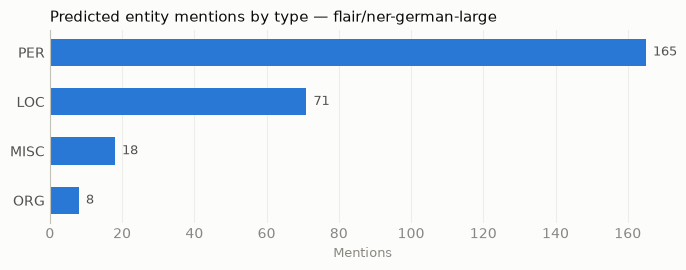

In [9]:
# Entity mentions by type — single series, so one hue and no legend.
SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, BASELINE, BLUE = "#898781", "#e1e0d9", "#c3c2b7", "#2a78d6"

counts = ents_df["label"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 0.6 + 0.55 * len(counts)), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.barh(counts.index, counts.values, color=BLUE, height=0.55)

for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, length=0)
for lbl in ax.get_yticklabels():
    lbl.set_color(INK2)
for b, v in zip(bars, counts.values):
    ax.text(v + counts.max() * 0.012, b.get_y() + b.get_height() / 2,
            f"{v:,}", va="center", color=INK2, fontsize=9)

ax.set_title("Predicted entity mentions by type — flair/ner-german-large",
             color=INK, loc="left", fontsize=11)
ax.set_xlabel("Mentions", color=MUTED, fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# Qualitative check: highlight entities inline for a few sentences.
# Each span shows its label text, so identity never relies on color alone.
import html as html_mod
from IPython.display import HTML, display

ENT_WASH = {
    "PER": "rgba(42,120,214,0.22)",   # blue
    "LOC": "rgba(235,104,52,0.25)",   # orange
    "ORG": "rgba(27,175,122,0.25)",   # aqua
    "MISC": "rgba(237,161,0,0.28)",   # yellow
}

def render_sentence(sent):
    spans = sorted(sent.get_spans("ner"), key=lambda s: s.start_position)
    out, cursor, text = [], 0, sent.text
    for sp in spans:
        out.append(html_mod.escape(text[cursor : sp.start_position]))
        out.append(
            f'<mark style="background:{ENT_WASH.get(sp.tag, GRID)};'
            f'padding:1px 3px;border-radius:3px">'
            f"{html_mod.escape(text[sp.start_position : sp.end_position])}"
            f'<sub style="font-size:0.7em;color:{INK2}"> {sp.tag}</sub></mark>'
        )
        cursor = sp.end_position
    out.append(html_mod.escape(text[cursor:]))
    return (
        f'<p style="background:{SURFACE};color:{INK};padding:6px 10px;'
        f'border-radius:4px;line-height:1.7">' + "".join(out) + "</p>"
    )

with_ents = [s for s in sentences if s.get_spans("ner")]
display(HTML("".join(render_sentence(s) for s in with_ents[:8])))

## 6. Manual review sample → precision/recall estimate

Since there is no gold data, we estimate quality by hand-checking a sample.
The cell below writes `ner_outputs/review_sample.csv` with one row per sentence:

| column | fill in |
|---|---|
| `predicted` | the model's entities (pre-filled) — read against the sentence |
| `n_wrong` | how many predicted entities are wrong (wrong span **or** wrong type) |
| `n_missed` | how many real entities the model missed entirely |
| `notes` | anything systematic (e.g. "building names never tagged") |

Open it in Excel/Numbers, fill the two count columns, and save as
**`ner_outputs/review_sample_annotated.csv`**. In Excel choose the format
**"CSV UTF-8 (Comma delimited)"** when saving, so umlauts survive the round-trip.
Then run the evaluation cell.

In [ ]:
rng = np.random.default_rng(SEED)
n_sample = min(REVIEW_SAMPLE_SIZE, len(sentences))
sample_ids = sorted(rng.choice(len(sentences), size=n_sample, replace=False))

review_rows = []
for i in sample_ids:
    spans = sentences[i].get_spans("ner")
    review_rows.append(
        {
            "sentence_id": i,
            "sentence": sentences[i].text,
            "predicted": " | ".join(f"{sp.tag}: {sp.text}" for sp in spans),
            "n_predicted": len(spans),
            "n_wrong": "",
            "n_missed": "",
            "notes": "",
        }
    )

review_df = pd.DataFrame(review_rows)
# utf-8-sig adds a BOM so Excel/Numbers detect the encoding (ä, ö, ü, ß)
review_df.to_csv(OUT_DIR / "review_sample.csv", index=False, encoding="utf-8-sig")
print(f"{len(review_df)} sentences → {OUT_DIR / 'review_sample.csv'}")
print(f"of which {int((review_df['n_predicted'] > 0).sum())} contain predicted entities")

In [ ]:
annotated_path = OUT_DIR / "review_sample_annotated.csv"

if not annotated_path.exists():
    print(f"Not found: {annotated_path}")
    print("Fill in review_sample.csv first, then save it under that name and re-run.")
else:
    # utf-8-sig also reads plain utf-8; tolerates Excel's re-saved BOM
    rev = pd.read_csv(annotated_path, encoding="utf-8-sig")
    rev[["n_predicted", "n_wrong", "n_missed"]] = (
        rev[["n_predicted", "n_wrong", "n_missed"]].fillna(0).astype(int)
    )
    n_pred = rev["n_predicted"].sum()
    n_wrong = rev["n_wrong"].sum()
    n_miss = rev["n_missed"].sum()
    tp = n_pred - n_wrong
    precision = tp / n_pred if n_pred else float("nan")
    recall = tp / (tp + n_miss) if (tp + n_miss) else float("nan")

    print(f"reviewed sentences : {len(rev)}")
    print(f"predicted entities : {n_pred}  (wrong: {n_wrong})")
    print(f"missed entities    : {n_miss}")
    print(f"precision ≈ {precision:.2%}")
    print(f"recall    ≈ {recall:.2%}\n")

    if precision >= 0.85 and recall >= 0.85:
        print("→ Zero-shot quality is sufficient: use the model as-is;")
        print("  fix residual errors via the review file or light post-processing rules.")
    else:
        print("→ Noticeable gaps: check the notes column for systematic errors.")
        print("  If errors cluster on OCR artifacts → improve the cleanup in step 2.")
        print("  If errors cluster on entity types the model doesn't know (buildings,")
        print("  artworks, dates) → annotate a few hundred sentences (start from the")
        print("  pre-annotations exported below) and fine-tune XLM-R Large.")

## 7. Export pre-annotations for labeling tools

If fine-tuning turns out to be necessary, don't annotate from scratch — import the model's
predictions into **doccano** (or Label Studio) and only *correct* them. The JSONL below is
doccano's span format: `{"text": ..., "label": [[start, end, tag], ...]}`.

In [ ]:
preann_path = OUT_DIR / "preannotations.jsonl"
with preann_path.open("w", encoding="utf-8") as f:
    for sent in sentences:
        labels = [
            [sp.start_position, sp.end_position, sp.tag]
            for sp in sent.get_spans("ner")
        ]
        f.write(
            json.dumps({"text": sent.text, "label": labels}, ensure_ascii=False) + "\n"
        )
print(f"{len(sentences)} sentences → {preann_path}")

## 8. Custom entity types with GLiNER (zero-shot)

The Flair model is locked to PER/LOC/ORG/MISC. **GLiNER** matches spans against
*arbitrary label names you type in* — no training data needed. We use the
multilingual checkpoint `urchade/gliner_multi-v2.1` (~1.2 GB, cached after first run)
and ask for **dates, buildings, artworks**.

Verified behavior on this corpus:

- **date** works very well (`1918` 0.85, `14. Juli 1778` 0.87, `11. Jahrhundert` 0.96) — trust scores ≥ 0.7
- **artwork** is usable (`Deckenmalereien` 0.72, `Altarblatt` 0.79)
- **building** is the noisiest — it found *Kirche zum Herzen Jesu in St. Fiden* (0.75) but
  also mislabeled a person (*Joh. Michael Grass*, 0.52) — treat scores below ~0.6 with suspicion

Tune `GLINER_LABELS` (English label names work best, even on German text) and
`GLINER_THRESHOLD` (raise to 0.5–0.6 for cleaner but fewer results). GLiNER results are
kept in a separate `gliner_entities.csv` — combine with the Flair entities downstream
as needed.

In [ ]:
# Run once per environment (already installed in the 'ner' env)
%pip install -q gliner

In [ ]:
from gliner import GLiNER

gliner_model = GLiNER.from_pretrained("urchade/gliner_multi-v2.1")

# Free-text label names — edit at will. English label names work best,
# even on German text. Threshold trades precision vs. recall.
GLINER_LABELS = ["date", "building", "artwork"]
GLINER_THRESHOLD = 0.4

gl_rows = []
for i, sent in enumerate(sentences):
    for ent in gliner_model.predict_entities(
        sent.text, GLINER_LABELS, threshold=GLINER_THRESHOLD
    ):
        gl_rows.append(
            {
                "sentence_id": i,
                "text": ent["text"],
                "label": ent["label"],
                "score": round(ent["score"], 3),
                "start": ent["start"],
                "end": ent["end"],
                "sentence": sent.text,
            }
        )

gliner_df = pd.DataFrame(gl_rows)
gliner_df.to_csv(OUT_DIR / "gliner_entities.csv", index=False, encoding="utf-8-sig")
print(f"{len(gliner_df)} spans → {OUT_DIR / 'gliner_entities.csv'}\n")
print(gliner_df["label"].value_counts(), "\n")
display(gliner_df.sort_values("score", ascending=False).head(15)[["text", "label", "score"]])
print("\nLow-confidence spans (most likely errors):")
display(gliner_df.sort_values("score").head(10)[["text", "label", "score", "sentence"]])

## Next steps & fallbacks

- **If precision/recall ≥ ~0.85:** ship the zero-shot pipeline. Add small post-processing
  rules for recurring errors (e.g. strip citation markers like *(Vad. I, S.365)* before tagging).
- **If entity types are missing** (buildings, artworks, dates): annotate ~300–500 sentences via the
  pre-annotations above, then fine-tune `xlm-roberta-large` with the Hugging Face `Trainer`
  (`AutoModelForTokenClassification`, `label_all_tokens=False`), exactly as in your CLT notebook setup.
- **If the text were older / heavier OCR noise** than this corpus: swap the tagger for an
  hmBERT-based HIPE-2022 checkpoint (search Hugging Face for "hmbert german ner") — same
  `SequenceTagger.load(...)` / `pipeline("token-classification", ...)` call, nothing else changes.
- **Quick sanity comparison** (optional): run the smaller `flair/ner-german` on the same sentences
  and diff the two entity tables — large disagreement zones are the best places to hand-check first.